# Base-pair ChIP- and ATAC-seq modeling

More detailed information on base-pair modeling is available at: 
https://github.com/jmschrei/bpnet-lite/tree/master
https://github.com/kundajelab/bpnet



For some processing steps, we will need classical tools to process sequencing files:
```
conda install -y -c bioconda samtools=1.1 bedtools ucsc-bedgraphtobigwig
```

## Experimental dataset

*(parts of the section were copied from https://github.com/kundajelab/bpnet)*

For this tutorial we'll use experimental CHIP-seq data, for the transcription factor **CTCF in the K562** cell line, which is available on the ENCODE data portal. There are 5 such experiments that we find in ENCODE, you can see them listed [here](https://www.encodeproject.org/search/?type=Experiment&status=released&replicates.library.biosample.donor.organism.scientific_name=Homo+sapiens&biosample_ontology.term_name=K562&assay_title=Histone+ChIP-seq&assay_title=TF+ChIP-seq&target.label=CTCF). 

We'll restrict ourselves to one experiment [ENCSR000EGM](https://www.encodeproject.org/experiments/ENCSR000EGM/)

#### Experiment bams

Download the .bam files for the two replicates for the experiment **ENCSR000EGM**. The two replicates are isogenic replicates (biological).

[ENCFF198CVB](https://www.encodeproject.org/files/ENCFF198CVB/@@download/ENCFF198CVB.bam)

[ENCFF488CXC](https://www.encodeproject.org/files/ENCFF488CXC/@@download/ENCFF488CXC.bam)

#### Control bams

Now download the bam files from control ENCSR000EHI for the experiment, which is available here:

[ENCFF023NGN](https://www.encodeproject.org/files/ENCFF023NGN/@@download/ENCFF023NGN.bam)

In [ ]:
%%bash
datadir=../data/ChIP
mkdir -p $datadir

wget --no-check-certificate https://www.encodeproject.org/files/ENCFF198CVB/@@download/ENCFF198CVB.bam -O ${datadir}/rep1.bam
wget --no-check-certificate https://www.encodeproject.org/files/ENCFF488CXC/@@download/ENCFF488CXC.bam -O ${datadir}/rep2.bam

wget --no-check-certificate https://www.encodeproject.org/files/ENCFF023NGN/@@download/ENCFF023NGN.bam -O ${datadir}/control.bam

#### Reference files and blacklist regions

Finally, download the reference files. In the example below, some preprocessing is required to filter out unwanted chromosomes from the hg38.chrom.sizes file. Additionally, the blacklist file shown is specific to hg38, and should be replaced with a genome-specific blacklist if alternative genomes are used.

##### Available Blacklists:

For those interested in using the blacklists, a current version for dm3, dm6, ce10, ce11, mm10, hg19, and hg38 are available in the lists/ folder at https://github.com/Boyle-Lab/Blacklist/

Please cite:

*Amemiya, H.M., Kundaje, A. & Boyle, A.P. The ENCODE Blacklist: Identification of Problematic Regions of the Genome. Sci Rep 9, 9354 (2019). https://doi.org/10.1038/s41598-019-45839-z*

In [ ]:
%%bash
datadir=../data/ChIP
cd $datadir
# download genome refrence
wget --no-check-certificate https://www.encodeproject.org/files/GRCh38_no_alt_analysis_set_GCA_000001405.15/@@download/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta.gz \
-O hg38.genome.fa.gz 
gunzip hg38.genome.fa.gz

# index genome reference
samtools faidx hg38.genome.fa

# download chrom sizes
wget --no-check-certificate https://www.encodeproject.org/files/GRCh38_EBV.chrom.sizes/@@download/GRCh38_EBV.chrom.sizes.tsv

# exclude alt contigs and chrEBV
grep -v -e '_' -e 'chrEBV' GRCh38_EBV.chrom.sizes.tsv > hg38.chrom.sizes
rm GRCh38_EBV.chrom.sizes.tsv

# make file with chromosomes only
awk '{print $1}' hg38.chrom.sizes > chroms.txt

# download blacklist
wget --no-check-certificate https://www.encodeproject.org/files/ENCFF356LFX/@@download/ENCFF356LFX.bed.gz -O blacklist.bed.gz
gunzip blacklist.bed.gz

## Preprocessing steps to generate bigwig counts tracks

#### 1. Merge the two replicates and create and index


In [ ]:
%%bash
datadir=../data/ChIP
cd $datadir
samtools merge -f merged.bam rep1.bam rep2.bam
samtools index merged.bam

# Index the control bam file
samtools index control.bam


#### 2. Create bigwig files using bedtools via intermediate bedGraph files

In addition to creating the bigwig files, at this step we will filter the bam files to keep only the chromosomes that we want to use in the model. In the example shown below, we do this using samtools view and the hg38.chrom.sizes reference file.

*** Here's a breakdown of each command in that pipeline: ***

```
samtools view -b merged.bam $(cut -f 1 hg38.chrom.sizes)
```

samtools view: Extracts/filters alignments from a BAM file
-b: Output in BAM format (binary)
$(cut -f 1 hg38.chrom.sizes): Substitutes the first column of the chrom.sizes file (chromosome names). This filters the BAM to only include these chromosomes, excluding any alternate contigs or unwanted sequences
bedtools genomecov -5 -bg -strand + -ibam stdin

bedtools genomecov: Calculates genome-wide coverage from aligned sequences
-5: Count only the 5' (start) positions of reads, not the entire read length (important for ChIP-seq peak calling)
-bg: Output as bedGraph format (4-column: chrom, start, end, coverage)
-strand +: Only count reads on the plus/forward strand
-ibam stdin: Read BAM input from the pipe (stdin) from the previous command
sort -k1,1 -k2,2n

sort: Sorts the bedGraph output
-k1,1: Sort by column 1 (chromosome) as strings
-k2,2n: Then sort by column 2 (start position) as numbers

This ordering is required by bedGraphToBigWig (the next step)

```
> plus.bedGraph
```
Redirects the sorted output to a file named plus.bedGraph

Summary: The pipeline filters the merged BAM file to specific chromosomes, extracts 5' read positions on the plus strand, calculates coverage, sorts it properly, and saves as a bedGraph file.

In [ ]:
# Don't execute at this time: We will use the peak specific processing below to generate per-base coverage files
%%bash
# See explanation of individual steps above
# get coverage of 5’ positions of the plus strand
samtools view -b merged.bam $(cut -f 1 hg38.chrom.sizes) | \
	bedtools genomecov -5 -bg -strand + -ibam stdin | \
	sort -k1,1 -k2,2n > plus.bedGraph

# get coverage of 5’ positions of the minus strand
samtools view -b merged.bam $(cut -f 1 hg38.chrom.sizes) | \
        bedtools genomecov -5 -bg -strand - -ibam stdin | \
        sort -k1,1 -k2,2n > minus.bedGraph

# Convert bedGraph files to bigWig files
bedGraphToBigWig plus.bedGraph hg38.chrom.sizes plus.bw
bedGraphToBigWig minus.bedGraph hg38.chrom.sizes minus.bw

# Control
# get coverage of 5’ positions of the control plus strand
samtools view -b control.bam $(cut -f 1 hg38.chrom.sizes) | \
        bedtools genomecov -5 -bg -strand + -ibam stdin | \
        sort -k1,1 -k2,2n > control_plus.bedGraph

# get coverage of 5' positions of the control minus strand
samtools view -b control.bam $(cut -f 1 hg38.chrom.sizes) | \
        bedtools genomecov -5 -bg -strand - -ibam stdin | \
        sort -k1,1 -k2,2n > control_minus.bedGraph

# Convert bedGraph files to bigWig files
bedGraphToBigWig control_plus.bedGraph hg38.chrom.sizes control_plus.bw
bedGraphToBigWig control_minus.bedGraph hg38.chrom.sizes control_minus.bw



#### 3. Identify peaks

For the purposes of this tutorial we will use the optimal IDR thresholded peaks that are already available in the ENCODE data portal. We will use the the narrowPeak files that are in BED6+4 format. Explanation of what each of the 10 fields means can be found here. Currently, only this format is supported but in the future support for more formats will be added.

In [ ]:
%%bash
datadir=../data/ChIP
cd $datadir
#Download the file:
wget https://www.encodeproject.org/files/ENCFF396BZQ/@@download/ENCFF396BZQ.bed.gz -O peaks.bed.gz
gunzip peaks.bed.gz

#### Preprocessing of bam files only witin bed file peaks, using Pysam

Instead of generating large genome-wide bedGraph files, we can also focus on the peak regions and only generate base-pair resolution profiles in those, and the matching negative regions.

In [ ]:
from tangermeme.match import extract_matching_loci
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
datadir = os.path.abspath("../data/ChIP/")
# Read in bed file with peaks, only keep first three columns
peaks = pd.read_csv(os.path.join(datadir, "peaks.bed"), sep="\t", header=None, usecols=[0,1,2], names=["chrom", "start", "end"])

# Compute the center position of each peak and the length
peaks["center"] = (peaks["start"] + peaks["end"]) // 2
peaks["length"] = peaks["end"] - peaks["start"]
print(f'Median peak length: {peaks["length"].median()}')
print(f'Mean peak length: {peaks["length"].mean()}')
signal_size = 500

# change start and end to center +- 250bp
peaks["start"] = peaks["center"] - 250
peaks["end"] = peaks["center"] + 250
print(f'Number of peaks before filtering: {len(peaks)}')

# keep only peaks that are at least signal_size away from chromosome ends
chrom_sizes = pd.read_csv(os.path.join(datadir, "hg38.chrom.sizes"), sep="\t", header=None, names=["chrom", "size"])
chrom_size_dict = dict(zip(chrom_sizes["chrom"], chrom_sizes["size"]))
def is_valid_peak(row):
    chrom_size = chrom_size_dict.get(row["chrom"], 0)
    return row["start"] >= signal_size and row["end"] <= (chrom_size - signal_size)
peaks = peaks[peaks.apply(is_valid_peak, axis=1)].reset_index(drop=True)
print(f'Number of valid peaks: {len(peaks)}')

# Remove peaks that are not in numbered chromosomes
peaks = peaks[peaks["chrom"].str.match(r'chr[0-9]+$')].reset_index(drop=True)
print(f'Number of peaks in numbered chromosomes: {len(peaks)}')

# Remove peaks that overlap blacklisted regions
blacklist = pd.read_csv(os.path.join(datadir, "blacklist.bed"), sep="\t", header=None, names=["chrom", "start", "end"])
def overlaps_blacklist(row):
    chrom = row["chrom"]
    start = row["start"]
    end = row["end"]
    overlapping = blacklist[(blacklist["chrom"] == chrom) & 
                            (blacklist["start"] < end) & 
                            (blacklist["end"] > start)]
    return not overlapping.empty
peaks = peaks[~peaks.apply(overlaps_blacklist, axis=1)].reset_index(drop=True)
print(f'Number of peaks after removing blacklisted regions: {len(peaks)}')

# Find matching negative loci for training
# Training negative loci are selected to match the GC content distribution of the positive peaks
# The model needs negative loci to learn what is not a peak
genome_fasta = os.path.join(datadir, "hg38.genome.fa")
neg_bed = extract_matching_loci(peaks, genome_fasta, in_window=signal_size, out_window=signal_size, max_n_perc=0.1, gc_bin_width=0.02, n_jobs=-1)
neg_bed.to_csv(os.path.join(datadir, "negative_loci.bed"), sep="\t", header=False, index=False)
print(f'Number of negative loci: {len(neg_bed)}')

# Save the filtered peaks
peaks.to_csv(os.path.join(datadir, "filtered_peaks.bed"), sep="\t", header=False, index=False, columns=["chrom", "start", "end"])

Median peak length: 240.0
Mean peak length: 207.23749213891412
Number of peaks before filtering: 57244
Number of valid peaks: 57221
Number of peaks in numbered chromosomes: 55477
Number of peaks after removing blacklisted regions: 55463
Number of negative loci: 55463


In [ ]:
import pysam
import numpy as np
import pandas as pd
import os

# Read positive loci
datadir = os.path.abspath("../data/ChIP/")
pos_loci = pd.read_csv(os.path.join(datadir, "filtered_peaks.bed"), sep="\t", header=None, names=["chrom", "start", "end"])
# Read negative loci
neg_loci = pd.read_csv(os.path.join(datadir, "negative_loci.bed"), sep="\t", header=None, names=["chrom", "start", "end"])

# merge positive and negative loci with labels
pos_loci["label"] = 1
neg_loci["label"] = 0
all_loci = pd.concat([pos_loci, neg_loci]).reset_index(drop=True)
print(f'Total number of loci: {len(all_loci)}')

# create a name column for each locus out of chrom + start + end + label
all_loci["name"] = all_loci['chrom'] + "_" + all_loci['start'].astype(str) + "_" + all_loci['end'].astype(str) + "_" + all_loci['label'].astype(str)

# Expand the regions by 500 bp on each side for sequence extraction
# We want the model to see some context around the peak when learning
# With 500 bp on each side, the input sequence length will be 1500 bp
# for every basepair prediction, it will have at least 500 bp of context on each side
all_loci["input_start"] = all_loci["start"] - 500
all_loci["input_end"] = all_loci["end"] + 500
print("Loci regions expanded by 500 bp on each side.")

# Extract sequences for all loci
genome_fasta = datadir + "hg38.genome.fa"
fasta = pysam.FastaFile(genome_fasta)
def extract_sequence(row):
    return fasta.fetch(row["chrom"], row["input_start"], row["input_end"])
all_loci["sequence"] = all_loci.apply(extract_sequence, axis=1)
print("Sequences extracted for all loci.")

# One-hot encode sequences
# Using function from seminar module
from gens2f_seminar_module.array_utils import seq_to_onehot
sequences = all_loci["sequence"].tolist()
onehot_sequences = np.array([seq_to_onehot(seq).T for seq in sequences])
print(f'One-hot encoded sequences shape: {onehot_sequences.shape}')

# Save one-hot encoded sequences and labels
np.savez(datadir + "loci_onehot.npz", sequences=onehot_sequences, names=all_loci["name"].values)
print("One-hot encoded sequences and names saved.")

Total number of loci: 110926
Loci regions expanded by 500 bp on each side.
Sequences extracted for all loci.
One-hot encoded sequences shape: (110926, 4, 1500)
One-hot encoded sequences and names saved.


In [ ]:
import pysam
import numpy as np
import pandas as pd
import os

# Read in bam files and create bigWig objects
rep_bam = pysam.AlignmentFile(os.path.join(datadir, "merged.bam"), "rb")
control_bam = pysam.AlignmentFile(os.path.join(datadir, "control.bam"), "rb")

# Count 5' read coverage for each locus
def count_5prime_coverage(bam_file, chrom, start, end):
    ''' 
    Count 5' read coverage for plus and minus strands in the given region.
    Arguments:
        bam_file: pysam.AlignmentFile object
        chrom: chromosome name
        start: start position (0-based)
        end: end position (0-based, exclusive)
    Returns:
        coverage: numpy array of shape (2, end-start) with coverage for plus and minus strands
    '''
    # Initialize coverage array for positive and negative strands
    coverage = np.zeros((2, end - start), dtype=np.int32)
    for read in bam_file.fetch(chrom, start, end):
        if not read.is_unmapped:
            if not read.is_reverse:
                pos = read.reference_start
                if start <= pos < end:
                    # 5' end on plus strand
                    coverage[0, pos - start] += 1
            else:
                # 5' end on minus strand needs to be shifted by 1
                pos = read.reference_end - 1
                if start <= pos < end:
                    # 5' end on minus strand
                    coverage[1, pos - start] += 1
        else:
            # handle unmapped reads if necessary
            # create empty coverage
            pass
            
    return coverage

# TODO: add this loop to function above to allow multiple locations in bam_file
# Compute coverages for all loci
coverages_rep = []
coverages_control = []
for idx, row in all_loci.iterrows():
    chrom = row["chrom"]
    start = row["start"]
    end = row["end"]
    if idx % 1000 == 0:
        print(f'Processing locus {idx}/{len(all_loci)}')
    cov_rep = count_5prime_coverage(rep_bam, chrom, start, end)
    cov_control = count_5prime_coverage(control_bam, chrom, start, end)
    coverages_rep.append(cov_rep)
    coverages_control.append(cov_control)
coverages_rep = np.array(coverages_rep)
coverages_control = np.array(coverages_control)
coverages = np.concatenate([coverages_rep, coverages_control], axis=1)
print(f'All coverages shape: {coverages.shape}')
coverage_tracks = ["rep_plus", "rep_minus", "control_plus", "control_minus"]

# Save coverages and labels
np.savez(datadir + "loci_BPcoverages.npz", signal=coverages, columns=coverage_tracks, names=all_loci["name"].values)
print("Coverages and names saved.")

Processing locus 0/110926
Processing locus 1000/110926
Processing locus 2000/110926
Processing locus 3000/110926
Processing locus 4000/110926
Processing locus 5000/110926
Processing locus 6000/110926
Processing locus 7000/110926
Processing locus 8000/110926
Processing locus 9000/110926
Processing locus 10000/110926
Processing locus 11000/110926
Processing locus 12000/110926
Processing locus 13000/110926
Processing locus 14000/110926
Processing locus 15000/110926
Processing locus 16000/110926
Processing locus 17000/110926
Processing locus 18000/110926
Processing locus 19000/110926
Processing locus 20000/110926
Processing locus 21000/110926
Processing locus 22000/110926
Processing locus 23000/110926
Processing locus 24000/110926
Processing locus 25000/110926
Processing locus 26000/110926
Processing locus 27000/110926
Processing locus 28000/110926
Processing locus 29000/110926
Processing locus 30000/110926
Processing locus 31000/110926
Processing locus 32000/110926
Processing locus 33000/

# Train base-pair resolution model

We use 1,500 bp sequences as input to predict the signal of 500 bp in the center with the forward and reverse strand

### Visualize the data

Data directory: /home/sasse/Git/GenomicS2F_seminar/data/ChIP
Loading coverage data from /home/sasse/Git/GenomicS2F_seminar/data/ChIP/loci_BPcoverages.npz
Total counts for rep_plus: 4361131
Total counts for rep_minus: 4366693
Total counts for control_plus: 280340
Total counts for control_minus: 279489
Max signal per locus: 2


/tmp/ipykernel_20215/3661016559.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axsc.boxplot([counts[positive_mask, i] for i in range(counts.shape[1])], positions=np.arange(counts.shape[1])*2.0-0.3, widths=0.6, labels=tracks, patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="blue"))
/tmp/ipykernel_20215/3661016559.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axsc.boxplot([counts[negative_mask, i] for i in range(counts.shape[1])], positions=np.arange(counts.shape[1])*2.0+0.3, widths=0.6, labels=tracks, patch_artist=True, boxprops=dict(facecolor="lightgreen"), medianprops=dict(color="green"))


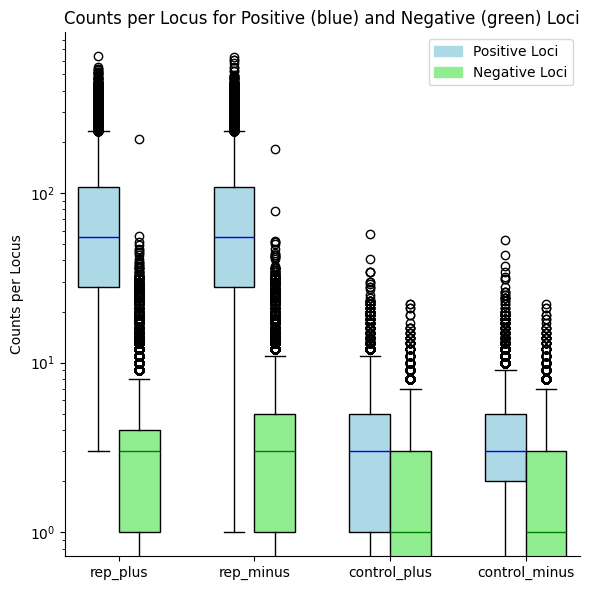

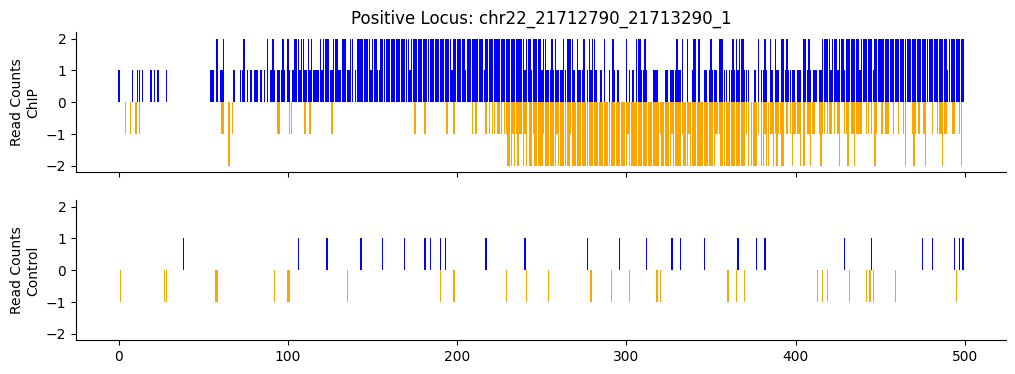

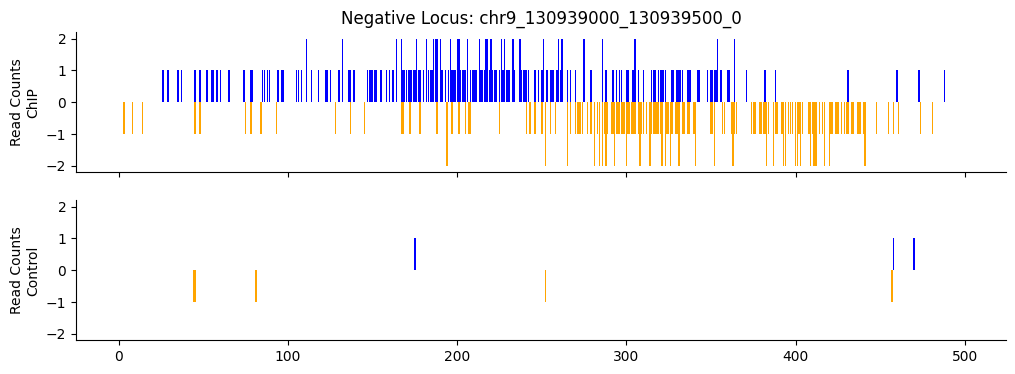

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

datadir = os.path.abspath("../data/ChIP/")
print(f'Data directory: {datadir}')
# Read in signal and names
print(f"Loading coverage data from {os.path.join(datadir, 'loci_BPcoverages.npz')}")
data = np.load(os.path.join(datadir, "loci_BPcoverages.npz"), allow_pickle=True)
signal = data["signal"]
names = data["names"]
tracks = data["columns"]

# Get the total number of counts per track
total_counts = signal.sum(axis=(0,2))
for i, track in enumerate(tracks):
    print(f'Total counts for {track}: {total_counts[i]}')
# Print max signal per locus
max_signal_per_locus = signal.max(axis=(1,2))
print(f'Max signal per locus: {max_signal_per_locus.max()}')

# Look at some statistics:
# Sum over last axis to get total signal per locus
counts = signal.sum(axis=2)
# Get masks for positive and negative loci
positive_mask = np.array([name.endswith("_1") for name in names])
negative_mask = np.array([name.endswith("_0") for name in names])
# Plot boxplots of counts per locus for positive and negative loci for all tracks
figc, axsc = plt.subplots(1,1, figsize=(6, 6))
axsc.boxplot([counts[positive_mask, i] for i in range(counts.shape[1])], positions=np.arange(counts.shape[1])*2.0-0.3, widths=0.6, labels=tracks, patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="blue"))
axsc.boxplot([counts[negative_mask, i] for i in range(counts.shape[1])], positions=np.arange(counts.shape[1])*2.0+0.3, widths=0.6, labels=tracks, patch_artist=True, boxprops=dict(facecolor="lightgreen"), medianprops=dict(color="green"))
axsc.set_title('Counts per Locus for Positive (blue) and Negative (green) Loci')
axsc.set_ylabel('Counts per Locus')
axsc.spines['top'].set_visible(False)
axsc.spines['right'].set_visible(False)
axsc.set_yscale('log')
# Create custom legend patches with colors
positive_patch = mpatches.Patch(color='lightblue', label='Positive Loci')
negative_patch = mpatches.Patch(color='lightgreen', label='Negative Loci')
axsc.legend(handles=[positive_patch, negative_patch])
axsc.set_xticks(np.arange(len(tracks))*2.0)
plt.tight_layout()
plt.show()


# Plot one positive and one negative locus with high signal
positive_idx = np.argsort(counts[positive_mask, 0])[-1]
positive_idx = np.where(positive_mask)[0][positive_idx]
negative_idx = np.argsort(counts[negative_mask, 0])[-1]
negative_idx = np.where(negative_mask)[0][negative_idx]

def plot_signal(ax, signal, title):
    ''' Not used currently
    TIP: create and use functions for plotting.'''
    ax.bar(np.arange(signal.shape[1]), signal[0, :], label="Plus Strand", color="blue")
    ax.bar(np.arange(signal.shape[1]), -signal[1, :], label="Minus Strand", color="orange")
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(-np.max(signal) * 1.1, np.max(signal) * 1.1)
    ax.legend()
    
figp, axsp = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axsp[0].bar(np.arange(signal.shape[2]), signal[positive_idx, 0, :], label="Replicate Plus", color="blue")
axsp[0].bar(np.arange(signal.shape[2]), -signal[positive_idx, 1, :], label="Replicate Minus", color="orange")
axsp[1].bar(np.arange(signal.shape[2]), signal[positive_idx, 2, :], label="Control Plus", color="blue")
axsp[1].bar(np.arange(signal.shape[2]), -signal[positive_idx, 3, :], label="Control Minus", color="orange")
axsp[0].set_title(f'Positive Locus: {names[positive_idx]}')
axsp[0].set_ylabel('Read Counts\nChIP')
axsp[0].spines['top'].set_visible(False)
axsp[0].spines['right'].set_visible(False)
axsp[1].spines['top'].set_visible(False)
axsp[1].spines['right'].set_visible(False)
axsp[1].set_ylabel('Read Counts\nControl')
axsp[0].set_ylim(-np.max(signal[positive_idx]) * 1.1, np.max(signal[positive_idx]) * 1.1)
axsp[1].set_ylim(-np.max(signal[positive_idx]) * 1.1, np.max(signal[positive_idx]) * 1.1)

fign, axsn = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axsn[0].bar(np.arange(signal.shape[2]), signal[negative_idx, 0, :], label="Replicate Plus", color="blue")
axsn[0].bar(np.arange(signal.shape[2]), -signal[negative_idx, 1, :], label="Replicate Minus", color="orange")
axsn[1].bar(np.arange(signal.shape[2]), signal[negative_idx, 2, :], label="Control Plus", color="blue")
axsn[1].bar(np.arange(signal.shape[2]), -signal[negative_idx, 3, :], label="Control Minus", color="orange")
axsn[0].set_title(f'Negative Locus: {names[negative_idx]}')
axsn[0].set_ylabel('Read Counts\nChIP')
axsn[0].spines['top'].set_visible(False)
axsn[0].spines['right'].set_visible(False)
axsn[1].spines['top'].set_visible(False)
axsn[1].spines['right'].set_visible(False)
axsn[1].set_ylabel('Read Counts\nControl')
axsn[0].set_ylim(-np.max(signal[negative_idx]) * 1.1, np.max(signal[negative_idx]) * 1.1)
axsn[1].set_ylim(-np.max(signal[negative_idx]) * 1.1, np.max(signal[negative_idx]) * 1.1)

plt.show()

## Start model training

Model training can be included into a python script similar to the script that you find under `scripts/train_model.py`

In [14]:
from gens2f_seminar_module import seqtofuncCNN, batched_predictions, batched_predictions_numpy, numpy_correlation_coefficient
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint, Callback
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger
from drg_tools.data_processing import generatetesttrain
import os
import numpy as np

In [15]:
# Load the data and use DRG function to create test/train splits
if __name__ == "__main__":
    datadir = os.path.abspath("../data/ChIP/")
    # Read in signal and names
    data = np.load(os.path.join(datadir, "loci_BPcoverages.npz"), allow_pickle=True)
    signal = data["signal"]
    names = data["names"]
    tracks = data["columns"]
    # Read in one-hot encoded sequences
    seq_data = np.load(os.path.join(datadir, "loci_onehot.npz"), allow_pickle=True)
    onehot_sequences = seq_data["sequences"]
    seq_names = seq_data["names"]
    print(f'Signal shape: {signal.shape}, One-hot sequences shape: {onehot_sequences.shape}')
    
    
    # Ensure names match
    assert np.array_equal(names, seq_names), "Names in signal and sequence files do not match!"
    print("Names in signal and sequence files match.")
    
    # Get the chromosome IDs from the names
    bed = np.array([name.split("_") for name in names])
    # bed columns: chrom, start, end, label
    


Signal shape: (110926, 4, 500), One-hot sequences shape: (110926, 4, 1500)
Names in signal and sequence files match.


In [ ]:
# (Optional) We might have to smooth the signal a bit to make learning easier
from gens2f_seminar_module import numpy_correlation_coefficient
import numpy as np
if __name__ == "__main__":
    smooth_window = 16
    smoothed_signal = np.array([np.convolve(signal[i, j, :], np.ones(smooth_window)/smooth_window, mode='same') for i in range(signal.shape[0]) for j in range(signal.shape[1])]).reshape(signal.shape)
    print("Signal smoothed with moving average.")
    # check the correlation between original and smoothed signal
    corr = numpy_correlation_coefficient(signal, smoothed_signal, axis=-1)
    print(f'Correlation between original and smoothed signal (per track): {corr.mean(axis=0)}')
    signal = smoothed_signal
    


Signal smoothed with moving average.
Correlation between original and smoothed signal (per track): [0.34947653 0.34922671 0.20011135 0.20029556]


Plotting signals with counts: Positive locus counts = 194.75, Negative locus counts = 9.6875


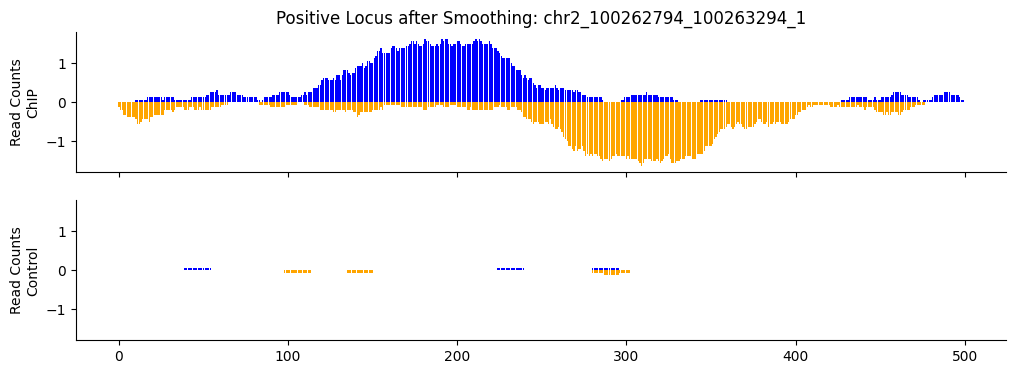

In [17]:
# plot two signal examples again to see the effect of smoothing
import matplotlib.pyplot as plt
signal_counts = signal.sum(axis=2)
# Plot one positive and one negative locus with high signal after smoothing
positive_idx = np.argsort(signal_counts[bed[:,3]=="1", 0])[-2500]
positive_idx = np.where(bed[:,3]=="1")[0][positive_idx]
negative_idx = np.argsort(signal_counts[bed[:,3]=="0", 0])[-2500]
negative_idx = np.where(bed[:,3]=="0")[0][negative_idx]
print(f'Plotting signals with counts: Positive locus counts = {signal_counts[positive_idx,0]}, Negative locus counts = {signal_counts[negative_idx,0]}')
figp, axsp = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axsp[0].bar(np.arange(signal.shape[2]), signal[positive_idx, 0, :], label="Replicate Plus", color="blue")
axsp[0].bar(np.arange(signal.shape[2]), -signal[positive_idx, 1, :], label="Replicate Minus", color="orange")
axsp[1].bar(np.arange(signal.shape[2]), signal[positive_idx, 2, :], label="Control Plus", color="blue")
axsp[1].bar(np.arange(signal.shape[2]), -signal[positive_idx, 3, :], label="Control Minus", color="orange")
axsp[0].set_title(f'Positive Locus after Smoothing: {names[positive_idx]}')
axsp[0].set_ylabel('Read Counts\nChIP')
axsp[0].spines['top'].set_visible(False)
axsp[0].spines['right'].set_visible(False)
axsp[1].spines['top'].set_visible(False)
axsp[1].spines['right'].set_visible(False)
axsp[1].set_ylabel('Read Counts\nControl')
axsp[0].set_ylim(-np.max(signal[positive_idx]) * 1.1, np.max(signal[positive_idx]) * 1.1)
axsp[1].set_ylim(-np.max(signal[positive_idx]) * 1.1, np.max(signal[positive_idx]) * 1.1)   
plt.show()

In [ ]:
# (Optional) Remove the controls from the signal for modeling if you think this has an impact on learning
if __name__ == "__main__":
    signal = signal[:, :2, :]  # Keep only replicate plus and minus strands
    print(f'Signal shape after removing controls: {signal.shape}')
    tracks = ["rep_plus", "rep_minus"]

In [18]:
if __name__ == "__main__":
    # Generate 10-fold cross-validation fold IDs based on chromosome
    fold_ids = generatetesttrain(names, bed[:,0], outname=None, kfold = 10, seed=42)

    # Select fold 0 as test set
    test_set_indices = np.isin(names, fold_ids[0])
    # And fold 1 as validation set
    validation_set_indices = np.isin(names, fold_ids[1])
    # Training set is all other indices
    training_set_indices = ~(test_set_indices | validation_set_indices)
    print(f"Training set size: {np.sum(training_set_indices)}")
    print(f"Validation set size: {np.sum(validation_set_indices)}")
    print(f"Test set size: {np.sum(test_set_indices)}")
    
    training_set_ids = names[training_set_indices]
    test_set_ids = names[test_set_indices]
    validation_set_ids = names[validation_set_indices]

Best split 84.6
0 ['chr9' 'chr6'] 117
1 ['chr1'] -138
2 ['chr11' 'chr8'] 57
3 ['chr5' 'chr4'] 42
4 ['chr7' 'chr19'] -59
5 ['chr3' 'chr16'] 141
6 ['chr10' 'chr12'] -223
7 ['chr18' 'chr2'] 1
8 ['chr20' 'chr17' 'chr22'] 21
9 ['chr13' 'chr15' 'chr14' 'chr21'] 47
Training set size: 88763
Validation set size: 10954
Test set size: 11209


In [ ]:
if __name__ == "__main__":
    # Create data sets and data loaders
    batch_size = 32
    subset_size = 16384 ### REMOVE or set to 100000000 
    
    ### Set to 1.0 if you don't want to scale the signal
    scale_factor = 100.0 ### (Optional, depends on loss function) Scale factor to multiply the signal values for better training stability in the exponential space
    
    X_train = onehot_sequences[np.where(training_set_indices)[0]][:subset_size]
    y_train = signal[np.where(training_set_indices)[0]][:subset_size] * scale_factor # Let's scale the signal for better training
    X_val = onehot_sequences[np.where(validation_set_indices)[0]][:subset_size]
    y_val = signal[np.where(validation_set_indices)[0]][:subset_size] * scale_factor
    X_test = onehot_sequences[np.where(test_set_indices)[0]][:subset_size]
    y_test = signal[np.where(test_set_indices)[0]][:subset_size] * scale_factor
    print(f'Training set shape: {X_train.shape}, {y_train.shape}')
    print(f'Validation set shape: {X_val.shape}, {y_val.shape}')
    print(f'Test set shape: {X_test.shape}, {y_test.shape}')
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                torch.tensor(y_val, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.float32))   
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    print("Data loaders created.")

Training set shape: (16384, 4, 1500), (16384, 4, 500)
Validation set shape: (10954, 4, 1500), (10954, 4, 500)
Test set shape: (11209, 4, 1500), (11209, 4, 500)
Data loaders created.


In [ ]:
if __name__ == "__main__":

    # Define model parameters
    # When we use deconv head, the model returns output of size (batch_size, output_dim, input_length//(pool_size**poolconvlayers))
    # If we don't pool at all, the output length is the same as input length
    # To compare to the original signal of size 500, we can either define 
    model_kwargs = {
    "input_channels": onehot_sequences.shape[1],
    "output_dim": signal.shape[1],
    "output_length": signal.shape[2], #  500, this needs to be defined based on the size of the output length
    "nd_conv0": 256,
    "kernel_size": 19,
    "convlayers": 2,
    "nd_conv1": 512,
    "convkernel_size": 7,
    "keep_size_padding": True,
    "activation_func": "relu",
    "conv_residuals_after": 1,
    "dilated_conv_layers": 7, # we are using dilated convs to increase receptive field from 19 to 11 + 2^(7-1)-1 * (11-1) = 641
    "nd_convdil": None,
    "dilconvkernel_size": 11,
    "dilated_conv_residuals_after": 7, # we use residual connections after all layers to help training, you could also try every 1, or every 2 layers
    "poolconvlayers": 0, # We are not using pooling in this model
    "nd_poolconv": None,
    "poolconvkernel_size": None,
    "pool_size": None,
    "pool_type": "max",
    "head_type": 'deconv', # we use deconv head to get per-base predictions
    "head_width": 1,  # we use a head width of 1 to only mix channels, not positions
    "head_depth": 0, # we are adding more depth to the head to increase model capacity
    "nd_head": 512,
    "out_activation_func": "exp", # use capped exponential to ensure positively scaled outputs
    "loss_func": "Logp1MSE", # Poisson loss is suitable for count data as well, but there was some instability in training
    "val_loss_func": None, # use same as training loss
    "learning_rate": 1e-2,
    "optimizer": "sgd",
    "sgd_momentum": 0.9, # momentum adds stability to sgd optimizer, by adding a fraction of previous update to current update
    'scheduler_type': 'cosine' # cosine learning rate scheduler changes the lr during training in form of a cosine curve
    }
    


In [95]:
# check model for correct output size
model = seqtofuncCNN(**model_kwargs)
print(model)
input = X_train[0:2]
output = model(torch.tensor(input, dtype=torch.float32), verbose=True)
print(f'Input shape: {input.shape}, Output shape: {output.shape}')

seqtofuncCNN(
  (conv0): Conv1d(4, 256, kernel_size=(19,), stride=(1,), padding=same)
  (activation0): ReLU()
  (convs): ModuleDict(
    (conv_0): Conv1d(256, 512, kernel_size=(7,), stride=(1,), padding=same)
    (batchnorm_0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation_0): ReLU()
    (conv_1): Conv1d(512, 512, kernel_size=(7,), stride=(1,), padding=same)
    (batchnorm_1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation_1): ReLU()
  )
  (resconvs): ModuleDict(
    (resconv_0): Conv1d(256, 512, kernel_size=(1,), stride=(1,), padding=same)
    (resconv_1): Identity()
  )
  (dilated_convs): ModuleDict(
    (dilated_conv_0): Conv1d(512, 512, kernel_size=(11,), stride=(1,), padding=same)
    (batchnorm_0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation_0): ReLU()
    (dilated_conv_1): Conv1d(512, 512, kernel_size=(11,), stride=(1,), paddin

In [54]:
# free cuda memory from all previous runs that got interrupted
import torch
import gc
gc.collect()
torch.cuda.empty_cache()


In [ ]:
if __name__ == "__main__":

    import pytorch_lightning as pl
    from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
    # Set random seeds for reproducibility
    pl.seed_everything(42)
    
    # Initialize the model
    model = seqtofuncCNN(**model_kwargs)
    #print(model)

    output_dir = os.path.abspath("../runs/BpChIPseq/")
    os.makedirs(output_dir, exist_ok=True)
    print(f"Output directory: {output_dir}")

    # Define directory to save model checkpoints
    checkpoint_dir = os.path.join(output_dir, 'BpCNNs')
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    # Define callbacks
    checkpoint_callback = ModelCheckpoint(
        monitor='val_loss',           #### ATTENTION: changed to train_loss for debugging, needs to be val_loss for real training
        dirpath=checkpoint_dir,
        filename='CNN-{epoch:02d}-{val_loss:.4f}',
        save_top_k=1,
        mode='min',
    )
    early_stopping_callback = EarlyStopping(
        monitor='val_loss',         #### ATTENTION: changed to train_loss for debugging, needs to be val_loss for real training
        patience=15,    # this is the number of epochs with no improvement after which training will be stopped
        mode='min'
    )
    # Define loggers
    logger = TensorBoardLogger(
        save_dir= os.path.join(output_dir,'logs/'),
        name='seqtofuncCNN'
    )
    csv_logger = CSVLogger(
        save_dir= os.path.join(output_dir,'logs/'),
        name='seqtofuncCNN'
    )
    # create a custom Callback for printing training and validation loss after each epoch
    class PrintLossCallback(Callback):
        def on_validation_epoch_end(self, trainer, pl_module):
            metrics = trainer.callback_metrics
            # Prefer epoch-aggregated metrics when available
            train_loss = metrics.get("train_loss", metrics.get("train_loss_epoch"))
            val_loss = metrics.get("val_loss", metrics.get("val_loss_epoch"))
            def fmt(x):
                try:
                    x = x.item() if hasattr(x, "item") else x
                    return f"{float(x):.6f}"
                except Exception:
                    return "N/A"
            trainer.print(f"Epoch {trainer.current_epoch + 1}: Train Loss: {fmt(train_loss)}, Val Loss: {fmt(val_loss)}")
    print_loss_callback = PrintLossCallback()

    # Define device
    device = "gpu" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Initialize the trainer
    trainer = pl.Trainer(
        max_epochs=100,
        accelerator=device,
        devices=1 if torch.cuda.is_available() else 0,
        callbacks=[checkpoint_callback, early_stopping_callback], #, print_loss_callback],
        logger=[csv_logger], #[logger, csv_logger],
        log_every_n_steps=min(np.sum(training_set_indices), subset_size) // batch_size,
        enable_progress_bar=True,
        deterministic=True,
    )
    '''
    # Test the model before training with a single sequence
    model.to('cuda')
    model.eval()
    with torch.no_grad():
        sample_input = torch.tensor(onehot_sequences[0:3], dtype=torch.float32).to('cuda')
        sample_output = model(sample_input)
        print(f"Sample input shape: {sample_input.shape}, Sample output shape: {sample_output.shape}")
    '''

    # Train the model
    trainer.fit(model, train_loader, val_loader)
    # Load the best model from checkpoint
    best_model_path = checkpoint_callback.best_model_path
    print(f"Best model saved at: {best_model_path}")
    

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type         | Params | Mode 
----------------------------------------------------------
0 | conv0            | Conv1d       | 19.7 K | train
1 | activation0      | ReLU         | 0      | train
2 | convs            | ModuleDict   | 2.8 M  | train
3 | resconvs         | ModuleDict   | 131 K  | train
4 | dilated_convs    | ModuleDict   | 20.2 M | train
5 | dilated_resconvs | ModuleDict   | 0      | train
6 | pred_head        | ModuleDict   | 2.1 K  | train
7 | loss_func        | Logp1ANYLoss | 0      | train
8 | val_loss_func    | Logp1ANYLoss | 0      | train
----------------------------------------------------------
23.1 M    Trainable params
0         Non-trainable params
23.1 M    Total params
92.419    Total estimated model params size (MB)
43        Modules in train mode
0         Module

Output directory: /home/sasse/Git/GenomicS2F_seminar/runs/BpChIPseq
Using device: gpu
Epoch 5:  66%|██████▌   | 338/512 [11:00<05:40,  0.51it/s, v_num=0, val_loss=2.080, val_train_loss=2.080, train_loss=1.320]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [55]:
# Load the lastest saved model from the best checkpoint and evaluate on the test set
saved_checkpoints = os.listdir(checkpoint_dir)
saved_checkpoints = [f for f in saved_checkpoints if f.endswith('.ckpt')]
saved_checkpoints.sort(key=lambda x: os.path.getmtime(os.path.join(checkpoint_dir, x)))
print(f"Available checkpoints: {saved_checkpoints}")
best_model_path = os.path.join(checkpoint_dir, saved_checkpoints[-1])
print(f"Loading best model from: {best_model_path}")
model = seqtofuncCNN.load_from_checkpoint(best_model_path)
model.eval()


Available checkpoints: ['CNN-epoch=04-val_loss=2.0752.ckpt']
Loading best model from: /home/sasse/Git/GenomicS2F_seminar/runs/BpChIPseq/BpCNNs/CNN-epoch=04-val_loss=2.0752.ckpt


seqtofuncCNN(
  (conv0): Conv1d(4, 256, kernel_size=(19,), stride=(1,), padding=same)
  (activation0): ReLU()
  (convs): ModuleDict(
    (conv_0): Conv1d(256, 512, kernel_size=(7,), stride=(1,), padding=same)
    (batchnorm_0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation_0): ReLU()
    (conv_1): Conv1d(512, 512, kernel_size=(7,), stride=(1,), padding=same)
    (batchnorm_1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation_1): ReLU()
  )
  (resconvs): ModuleDict(
    (resconv_0): Conv1d(256, 512, kernel_size=(1,), stride=(1,), padding=same)
    (resconv_1): Identity()
  )
  (dilated_convs): ModuleDict(
    (dilated_conv_0): Conv1d(512, 512, kernel_size=(11,), stride=(1,), padding=same)
    (batchnorm_0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation_0): ReLU()
    (dilated_conv_1): Conv1d(512, 512, kernel_size=(11,), stride=(1,), paddin

In [25]:

# Make predictions on the test set
y_test_preds = batched_predictions(model, test_loader, device='cuda')
y_test_preds = y_test_preds.numpy()

# Alternatively, use numpy batched predictions
#from gens2f_seminar_module import batched_predictions_numpy
#y_test_preds_np = batched_predictions_numpy(model, X_test, batch_size=32, device='cuda')
y_test_true = y_test
print(f"Test predictions shape: {y_test_preds.shape}, Test true shape: {y_test_true.shape}")



Test predictions shape: (11209, 4, 500), Test true shape: (11209, 4, 500)


In [ ]:
# (For debugging) Make predictions on the train set
# Alternatively, use numpy batched predictions
from gens2f_seminar_module import batched_predictions_numpy
y_train_preds = batched_predictions_numpy(model, X_train, batch_size=32, device='cuda')
y_train_true = y_train
print(f"Train predictions shape: {y_train_preds.shape}, Train true shape: {y_train_true.shape}")

Train predictions shape: (128, 4, 500), Train true shape: (128, 4, 500)


In [34]:
from gens2f_seminar_module.modules import numpy_correlation_coefficient
# Determine the test set labels from the names
test_labels = np.array([int(name.endswith("_1")) for name in test_set_ids])[:subset_size]

# Compute correlation coefficients per track for positive loci only
bp_correlations = []
for i in range(y_test_true.shape[1]):
    corr = numpy_correlation_coefficient(y_test_true[test_labels==1, i, :], y_test_preds[test_labels==1, i, :], axis = -1)
    bp_correlations.append(corr)
    print(f"Track: {tracks[i]}, BP profile Correlation: {np.mean(corr):.4f}")

# Compute the average correlation of total counts across all tracks
correlations = []
for i in range(y_test_true.shape[1]):
    corr = numpy_correlation_coefficient(y_test_true[:, i, :].sum(axis=-1), y_test_preds[:, i, :].sum(axis=-1), axis = None)
    correlations.append(corr)
    print(f"Track: {tracks[i]}, total count Correlation: {corr:.4f}")




Track: rep_plus, BP profile Correlation: 0.7507
Track: rep_minus, BP profile Correlation: 0.7581
Track: control_plus, BP profile Correlation: 0.0650
Track: control_minus, BP profile Correlation: 0.0655
Track: rep_plus, total count Correlation: 0.4265
Track: rep_minus, total count Correlation: 0.4576
Track: control_plus, total count Correlation: 0.0943
Track: control_minus, total count Correlation: 0.1036


In [ ]:
# (For debugging) Test if model can overfit
from gens2f_seminar_module.modules import numpy_correlation_coefficient
# Determine the train set labels from the names
train_labels = np.array([int(name.endswith("_1")) for name in training_set_ids])[:subset_size]
print('negative:', (train_labels == 0).sum(), 'positive:', (train_labels == 1).sum())
# Compute correlation coefficients per track for positive loci only
bp_correlations = []
for i in range(y_train_true.shape[1]):
    corr = numpy_correlation_coefficient(y_train_true[train_labels==1, i, :], y_train_preds[train_labels==1, i, :], axis = -1)
    bp_correlations.append(corr)
    print(f"Track: {tracks[i]}, BP profile Correlation: {np.mean(corr):.4f}")

# Compute the average correlation of total counts across all tracks
correlations = []
colors = train_labels.astype(float)
for i in range(y_train_true.shape[1]):
    corr = numpy_correlation_coefficient(y_train_true[:, i, :].sum(axis=-1), y_train_preds[:, i, :].sum(axis=-1), axis = None)
    correlations.append(corr)
    print(f"Track: {tracks[i]}, total count Correlation: {corr:.4f}")
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,6))
    plt.scatter(y_train_true[:, i, :].sum(axis=-1), y_train_preds[:, i, :].sum(axis=-1), alpha=0.5, c=colors, cmap='viridis')
    plt.xlabel('True Total Counts')
    plt.ylabel('Predicted Total Counts')
    plt.show()

Best index: 4146
Name: chr6_18823754_18824254_1
correlations: [np.float64(0.9790637377258924), np.float64(0.9106615941909664), np.float64(0.28636740903006475), np.float64(0.007852702538606437)]
Max true signal track rep_plus: 131.25, Max predicted signal: 14.43414306640625
Correlation track rep_plus: 0.9791
Max true signal track rep_minus: 112.5, Max predicted signal: 20.560253143310547
Correlation track rep_minus: 0.9107


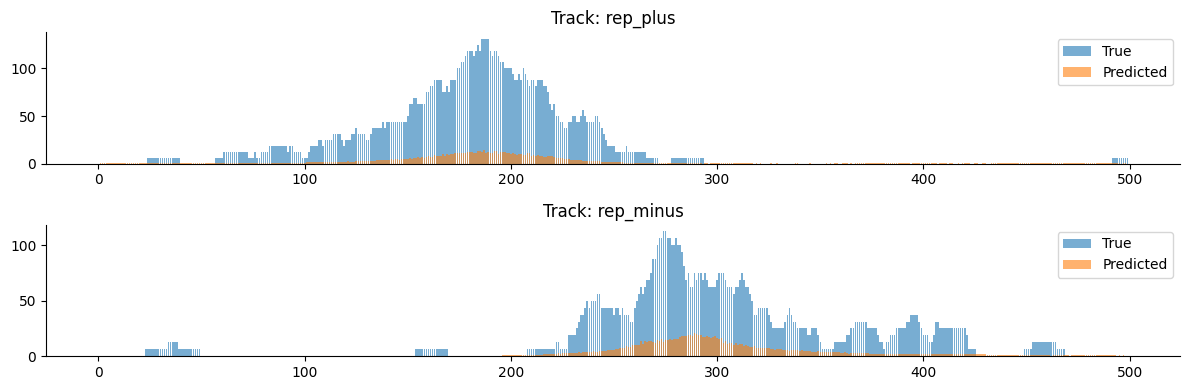

In [37]:
# Plot predicted vs true counts for the first two tracks for TEST set
import matplotlib.pyplot as plt
# select the data point with the best correlations
index = np.argsort(y_test_true.sum(axis=2)[test_labels == 1, 0])[-1]
index = np.argsort(bp_correlations[0])[ -1]  # select the index with the highest correlation for the first track
best_index = np.where(test_labels == 1)[0][index]
print(f'Best index: {best_index}')
print(f'Name: {test_set_ids[best_index]}') 
print(f'correlations: {[bp_correlations[i][index] for i in range(len(tracks))]}')

fig, axs = plt.subplots(2, 1, figsize=(12, 4))
for i in range(2):
    axs[i].bar(np.arange(y_test_true.shape[2]), y_test_true[best_index, i, :], label="True", alpha=0.6)
    axs[i].bar(np.arange(y_test_true.shape[2]), y_test_preds[best_index, i, :], label="Predicted", alpha=0.6)
    print(f'Max true signal track {tracks[i]}: {y_test_true[best_index, i, :].max()}, Max predicted signal: {y_test_preds[best_index, i, :].max()}')
    print(f'Correlation track {tracks[i]}: {numpy_correlation_coefficient(y_test_true[best_index, i, :][np.newaxis, :], y_test_preds[best_index, i, :][np.newaxis, :], axis=-1)[0]:.4f}')
    axs[i].set_title(f'Track: {tracks[i]}')
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].legend()
plt.tight_layout()
plt.show()

### Get sequence attributions

Our base-pair model generates 500 predictions for each track. Correspondingly, we can create 500 attribution maps for every single base-pair prediction. However, this approach is not only cumbersome and computationally inefficient, but also provides limited biological insight. A more meaningful approach is to identify which bases contribute to the signal within shifted peaks specifically. To achieve this, we isolate regions with strong signal from individual peaks and compute the attributions for those peak locations.

In [84]:
# Now one can generate attributions for individual base pairs using e.g. Integrated Gradients or DeepLIFT from Captum
import sys
from captum.attr import IntegratedGradients, DeepLift

# Use a wrapper to extract the attributions for selected base pairs with a mask

class BpCNNWrapper(nn.Module):
    def __init__(self, model, track = None):
        '''  
        Wrapper for the seqtofuncCNN model to extract attributions for specific base pair positions.
        The model output is of shape (batch_size, output_dim)
        and we want to sum over the output length dimension for selected positions.
        Arguments:
            model: seqtofuncCNN model
            track: int or None, if specified, only compute attributions for this output track
            if not specified, take the sum over all output tracks
            THIS is required for it to work with masks
        '''
        super(BpCNNWrapper, self).__init__()
        self.model = model
        self.track = track

    def forward(self, x, position_mask = None, verbose=False, warnings=True):
        '''  
        Forward pass through the model.
        Arguments:
            x: input tensor of shape (batch_size, input_channels, input_length)
            position_mask: tensor of shape (num_positions,) or (batch_size, num_positions)
                           specifying the positions to extract from the output. If None, use all positions.
        Returns:
            output: tensor of shape (batch_size, output_dim) with summed outputs over specified positions
        '''
        output = self.model(x)
        if self.track is not None:
            output = output[:, self.track, :]  # Select only the specified track
        else:
            output = output.sum(dim=1)  # Sum over all tracks
        if verbose:
            print(f'Output shape before applying position mask: {output.shape}')
        if position_mask is not None:
            # Extract the output for the specified positions
            if len(position_mask.shape) == 1:
                output = output[:, position_mask].sum(dim=-1, keepdim=True)
                if verbose:
                    print(f'Output shape after applying position mask: {output.shape}')
            elif len(position_mask.shape) == 2 and position_mask.shape[0] == x.shape[0]:
                batch_size = x.shape[0]
                output = torch.stack([output[b, position_mask[b]].sum(dim=-1, keepdim=True) for b in range(batch_size)])
                if verbose:
                    print(f'Output shape after applying batch position mask: {output.shape}')
            else:
                raise ValueError("position_mask must be 1D or 2D with batch size")
        else:
            if warnings:
                print(f'No position mask provided, summing over all positions.')
            output = output.sum(dim=-1, keepdim=True)  # Sum over all positions if no mask is provided

        return output  # Sum over the output length dimension

wrapped_model = BpCNNWrapper(model, track=0)
wrapped_model.eval().to('cuda')

# Select a test locus to explain
locus_index = best_index  # Using the best index from above
input_sequence = torch.tensor(X_test[locus_index:locus_index+1], dtype=torch.float32).to('cuda')

# check model output for this sequence
#with torch.no_grad():
#    model_output = wrapped_model(input_sequence)
#    print(f'Model output for selected locus: {model_output.shape}, values: {model_output.cpu().numpy()}')

# Define position mask for the center position (position 130-230)
position_mask = torch.zeros(1, y_test.shape[2])
position_mask[0, 130:250] = 1
position_mask = position_mask.bool()
position_mask = position_mask.to('cuda')

# check model output for this sequence
#with torch.no_grad():
#    model_output = wrapped_model(input_sequence, position_mask=position_mask)
#    print(f'Model output for selected locus with position mask: {model_output.shape}, values: {model_output.cpu().numpy()}')

# Initialize Integrated Gradients
ig = IntegratedGradients(wrapped_model, multiply_by_inputs=False)
baseline_sequence = torch.ones_like(input_sequence)*0.25
baseline_sequence = baseline_sequence.to('cuda')

# Compute attributions for replicate plus strand (track 0)
attributions_rep_plus = ig.attribute(input_sequence, target=0, baselines=baseline_sequence, additional_forward_args=position_mask, n_steps=50)
# hypothetical attributions
hyp_attributions_rep_plus = attributions_rep_plus - (attributions_rep_plus * baseline_sequence).sum(dim=-2, keepdim=True)

# Convert attributions to CPU numpy array for plotting
hyp_attributions_rep_plus = hyp_attributions_rep_plus.cpu().detach().numpy()
wrapped_model.to('cpu');  # free GPU memory

In [85]:
# Create attributions for negative strand with a new wrapper
wrapped_model_neg = BpCNNWrapper(model, track=1)
wrapped_model_neg.eval().to('cuda')

# We need aother position mask that caputure the peak in the negative strand signal for position (position 225-375)
position_mask = torch.zeros(1, y_test.shape[2])
position_mask[0, 225:375] = 1
position_mask = position_mask.bool()
position_mask = position_mask.to('cuda')
ig_neg = IntegratedGradients(wrapped_model_neg, multiply_by_inputs=False)
# Compute attributions for replicate minus strand (track 1)
attributions_rep_minus = ig_neg.attribute(input_sequence, target=0, baselines=baseline_sequence, additional_forward_args=position_mask, n_steps=50)
# hypothetical attributions
hyp_attributions_rep_minus = attributions_rep_minus - (attributions_rep_minus * baseline_sequence).sum(dim=-2, keepdim=True)

# Convert attributions to CPU numpy array for plotting
hyp_attributions_rep_minus = hyp_attributions_rep_minus.cpu().detach().numpy()
wrapped_model_neg.to('cpu');  # free GPU memory

In [59]:
print(f'Attributions shape: {hyp_attributions_rep_plus.shape}')
print(f'sequence shape: {X_test.shape}')

Attributions shape: (1, 4, 1500)
sequence shape: (11209, 4, 1500)


Combined attributions shape: (2, 500, 4)
Sequence shape: (1, 500, 4)


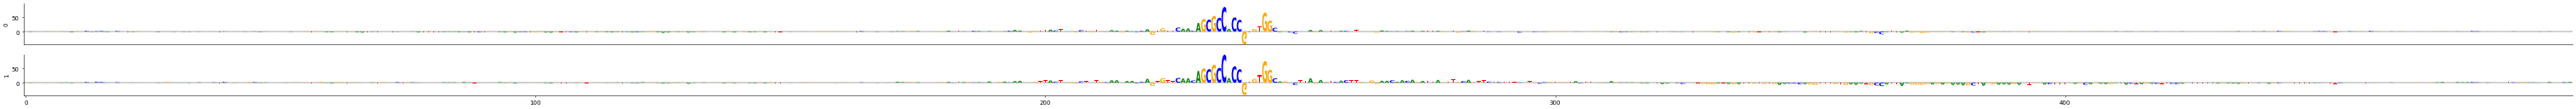

In [86]:

# Plot attributions for replicate plus strand
import matplotlib.pyplot as plt
from drg_tools.plotlib import plot_attribution_maps
hyp_attributions = np.transpose(np.concatenate([hyp_attributions_rep_plus, hyp_attributions_rep_minus], axis=0), (0, 2, 1))
hyp_attributions = hyp_attributions[:, 500:1000, :]
plot_sequence = np.transpose(X_test[locus_index:locus_index+1], (0, 2, 1))[:,500:1000, :]
print(f'Combined attributions shape: {hyp_attributions.shape}')
print(f'Sequence shape: {plot_sequence.shape}')
fig = plot_attribution_maps(hyp_attributions * plot_sequence)

In [90]:
# Since we modeled the also the control, we want to subtract the control signal, to remove the sequence parts that come other elements
# which for example come from open chromatin or mappability biases.
# For simplicity, we could have subtracted the control signal from the ChIP signal before modeling.
# However, here we only subtract the parts of the control that can also be explained by the sequence, and ignore noise in the control signal.
class DiffTrackCNNWrapper(nn.Module):
    def __init__(self, model, pos_tracks=[0,1], neg_tracks=[2,3]):
        super(DiffTrackCNNWrapper, self).__init__()
        self.model = model
        self.pos_tracks = pos_tracks
        self.neg_tracks = neg_tracks
    def forward(self, x):
        output = self.model(x)
        pos_output = output[:, self.pos_tracks, :].sum(dim=1, keepdim=True)
        neg_output = output[:, self.neg_tracks, :].sum(dim=1, keepdim=True)
        diff_output = pos_output - neg_output
        return diff_output

diff_model = DiffTrackCNNWrapper(model, pos_tracks=[0,1], neg_tracks=[2,3]) 
# now we put this wrapper back into the BpCNNWrapper
diff_model = BpCNNWrapper(diff_model, track=0)  # we want all tracks summed
diff_model.eval().to('cuda')
# Initialize Integrated Gradients for the difference model
ig_diff = IntegratedGradients(diff_model, multiply_by_inputs=False)
# create position mask that captures both peaks
position_mask = torch.zeros(1, y_test.shape[2])
position_mask[0, 130:375] = 1
position_mask = position_mask.bool()
position_mask = position_mask.to('cuda')
# Compute attributions for the difference model
attributions_diff = ig_diff.attribute(input_sequence, target=0, baselines=baseline_sequence, additional_forward_args=position_mask, n_steps=50)
# hypothetical attributions
hyp_attributions_diff = attributions_diff - (attributions_diff * baseline_sequence).sum(dim=-2, keepdim=True)
# Convert attributions to CPU numpy array for plotting
hyp_attributions_diff = hyp_attributions_diff.cpu().detach().numpy()
diff_model.to('cpu');  # free GPU memory

Difference attributions shape: (1, 500, 4)
Sequence shape: (1, 500, 4)


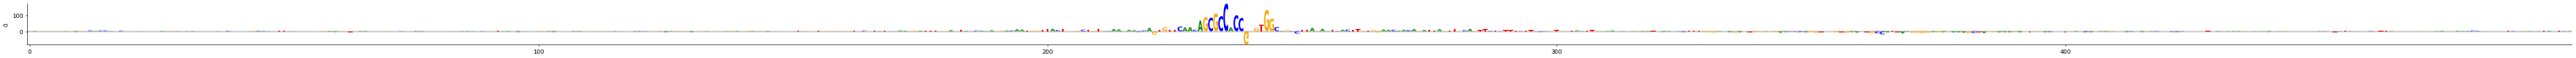

In [91]:
# Plot the attributions for the difference model
import matplotlib.pyplot as plt
from drg_tools.plotlib import plot_attribution_maps
hyp_attributions_diff = np.transpose(hyp_attributions_diff, (0, 2, 1))[:, 500:1000, :]
plot_sequence = np.transpose(X_test[locus_index:locus_index+1], (0, 2, 1))[:,500:1000, :]
print(f'Difference attributions shape: {hyp_attributions_diff.shape}')
print(f'Sequence shape: {plot_sequence.shape}')
fig = plot_attribution_maps(hyp_attributions_diff * plot_sequence)

Removing the control tracks may not have made a huge difference here but for some regions this can clean up the signal. 